✅ Step 1: Data Preparation

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

✅ Step 2: Define Network Architecture

In [10]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

c:\Users\DHRUV KUMAR\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ Step 3: Compile and Train the Network

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.8593 - loss: 0.4746 - val_accuracy: 0.9599 - val_loss: 0.1344
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9635 - loss: 0.1228 - val_accuracy: 0.9651 - val_loss: 0.1142
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9770 - loss: 0.0802 - val_accuracy: 0.9751 - val_loss: 0.0853
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9811 - loss: 0.0594 - val_accuracy: 0.9721 - val_loss: 0.0993
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9857 - loss: 0.0422 - val_accuracy: 0.9717 - val_loss: 0.0975
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9898 - loss: 0.0308 - val_accuracy: 0.9715 - val_loss: 0.1088
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.9907 - loss: 0.0284 - val_accuracy: 0.9713 - val_loss: 0.1097
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9920 -

✅ Step 4: Evaluate the Model

In [12]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9722 - loss: 0.1069
Test Accuracy: 0.9760
Test Loss: 0.0933


✅ Step 5: Hyperparameter Tuning (Example)

In [13]:
def train_model(learning_rate, batch_size):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(784,)),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(x_train, y_train, epochs=10, batch_size=batch_size, validation_split=0.2, verbose=0)
    return history

In [17]:
learning_rates = [0.01, 0.001, 0.0001]
batch_sizes = [32, 64, 128]

#  Example of testing different hyperparameters
for lr in learning_rates:
    for bs in batch_sizes:
        print(f"Training with LR={lr}, Batch size={bs}")
        history = train_model(lr, bs)
        # Optionally, print or plot results for each setting

Training with LR=0.01, Batch size=32


c:\Users\DHRUV KUMAR\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training with LR=0.01, Batch size=64
Training with LR=0.01, Batch size=128
Training with LR=0.001, Batch size=32
Training with LR=0.001, Batch size=64
Training with LR=0.001, Batch size=128
Training with LR=0.0001, Batch size=32
Training with LR=0.0001, Batch size=64
Training with LR=0.0001, Batch size=128


✅ Step 6: Visualization

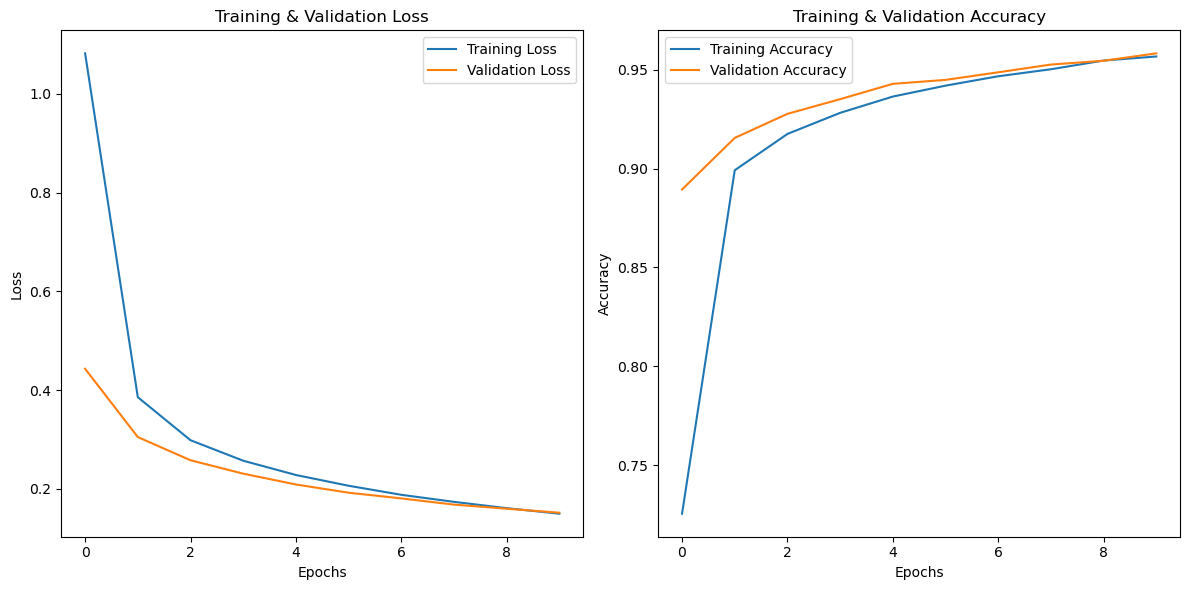

In [18]:
plt.figure(figsize=(12, 6))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


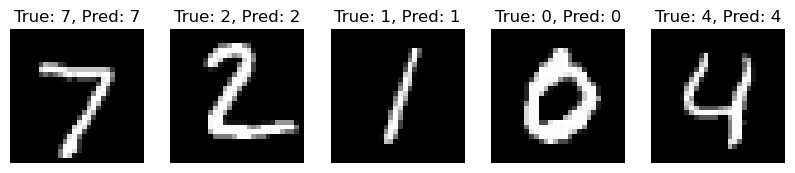

In [22]:
predictions = model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

plt.figure(figsize=(10, 10))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"True: {true_labels[i]}, Pred: {predicted_labels[i]}")
    plt.axis('off')
plt.show()

In [ ]:
model.save('mnist_digit_classifier.h5')

np.save('training_history.npy', history.history)